# Recovering the Unrecoverable — Yamborano Fresco Damage Mapping Notebook

### Author: Desislava S. Georgieva, PhD in Art History
*Accompanying Notebook for Zenodo Publication & Research Paper*

# 1. Introduction

This notebook accompanies the research article **Recovering the Unrecoverable: Documenting and Interpreting a Vanishing Bulgarian National Revival Fresco Cycle** and provides a reproducible computational workflow supporting the presented methodology.

Its purpose is not to perform automatic conservation diagnosis, nor to replace expert art-historical interpretation. Instead, it provides a transparent and reproducible computational workflow for documenting the visible loss of painted surface recorded in a historical photograph of the Yamborano mural cycle.

All image-processing operations presented here rely exclusively on open-source Python libraries. The workflow has been intentionally designed to remain transparent, reproducible and adaptable to other deteriorated mural ensembles documented through high-quality photographic material.

# 2. Research Objectives

The principal objective of this notebook is to produce a reproducible quantitative estimate of visible surface loss within the preserved mural cycle.

Rather than analysing artistic style or iconography, the computational workflow concentrates on distinguishing two visually observable categories:

- Preserved painted surface;
- Exposed plaster resulting from paint detachment.

After separating these regions, the notebook calculates the proportion of visible loss for each individual scene and compares the obtained values across the cycle.

These measurements complement the qualitative observations presented in the accompanying article and provide numerical evidence for the current state of preservation.

### Specific Objectives

The notebook pursues the following objectives:

- To load and preprocess the archival photograph;
- To identify regions corresponding to preserved paint and exposed plaster;
- To generate binary damage maps through colour-based segmentation;
- To calculate the percentage of preserved and damaged painted surface;
- To visualise the segmentation results;
  To pprovide reproducible numerical outputs supporting the accompanying research article.

### Expected Outcome

At the end of the workflow, the notebook will produce:

- A processed image suitable for computational analysis;
- Binary maps separating preserved and damaged areas;
- Quantitative measurements of surface loss;
- Graphical visualisations of the segmentation results;
- Reproducible numerical data that can be directly incorporated into the accompanying publication.

**The notebook does not attempt automatic conservation diagnosis. Instead, it provides a transparent computational workflow for measuring visible surface loss recorded in a historical photograph, allowing every processing step to be reproduced and critically evaluated.**

# 3. Notebook Organization

The notebook is organised into fourteen consecutive sections that reproduce the complete computational workflow, from data preparation to quantitative analysis and interpretation.


| Section | Contents |
|----------|----------|
| 1 | Introduction |
| 2 | Research Objectives |
| 3 | Notebook Organization  |
| 4 | Computational Workflow |
| 5 | Study Image |
| 6 | Traditional Documentation of Cultural Heritage |
| 7 | Import Libraries |
| 8 | Scene Separation |
| 9 | Quantitative Calculation and Statistics (Quantification) |
|10 | Graphical visualization of the results |
|11 | Conclusion |
|12 | Future Work |
|13 | References |
|14 | Acknowledgements |

# 4. Computational Workflow

The computational workflow consists of six consecutive stages designed to transform the original archival photograph into reproducible quantitative measurements of surface deterioration.

- Image preparation;
- Separation of the four painted scenes;
- Colour-space transformation;
- Surface-loss segmentation;
- Quantitative measurement;
- Presentation of numerical results.



Each stage builds upon the previous one, ensuring methodological transparency and complete reproducibility of the analytical workflow, and contributes directly to the final objective of estimating the visible extent of paint loss.

# 5. Study Image

This section introduces the geographical location of the study site and the archival photograph analysed throughout this notebook.

## 5.1. Geographic Location of the Study Site

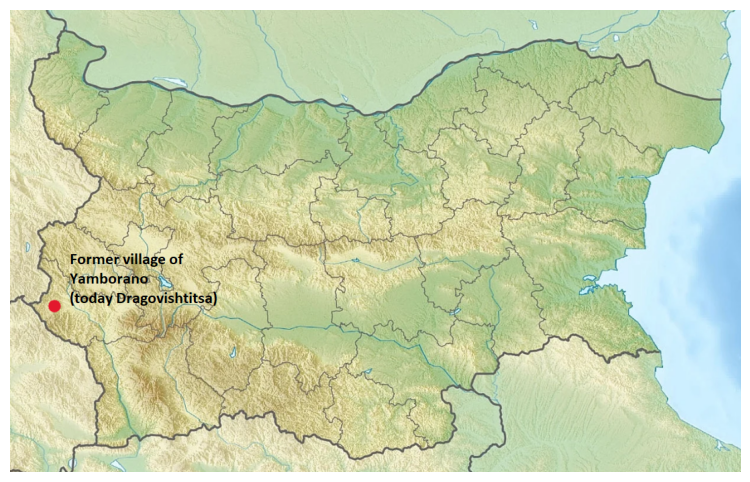

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

map_image = Image.open("map.png")

plt.figure(figsize=(10,6))
plt.imshow(map_image)
plt.axis("off")

plt.show()

**Figure 1.** Geographic location of the former village of Yamborano (today Dragovishtitsa), Kyustendil Municipality, Bulgaria. 

Figure 1 presents the geographical location of the former village of Yamborano (today Dragovishtitsa, Kyustendil Province, Bulgaria), where the investigated fresco cycle is preserved. The wall paintings survive within the former church of The Dormition of the Mother of God, a nineteenth-century Bulgarian National Revival monument currently in an advanced state of deterioration. The present study focuses exclusively on the surviving photographic documentation of the Festal cycle preserved on the barrel vault.

## 5.2. Loading and Initial Preparation of the Study Image

The photograph includes four surviving scenes from the cycle of the Great Feasts of the Orthodox Church:

- **The Transfiguration**
- **The Ascension**
- **The Entry into Jerusalem**
- **The Pentecost**

The authorship of the wall paintings is currently **unknown**, and their exact date of execution has not been established.

The image is used exclusively as a case study for demonstrating a reproducible computational workflow for documenting surface deterioration from a single archival colour photograph.

The image has been successfully loaded. Dimensions:1234x816 px


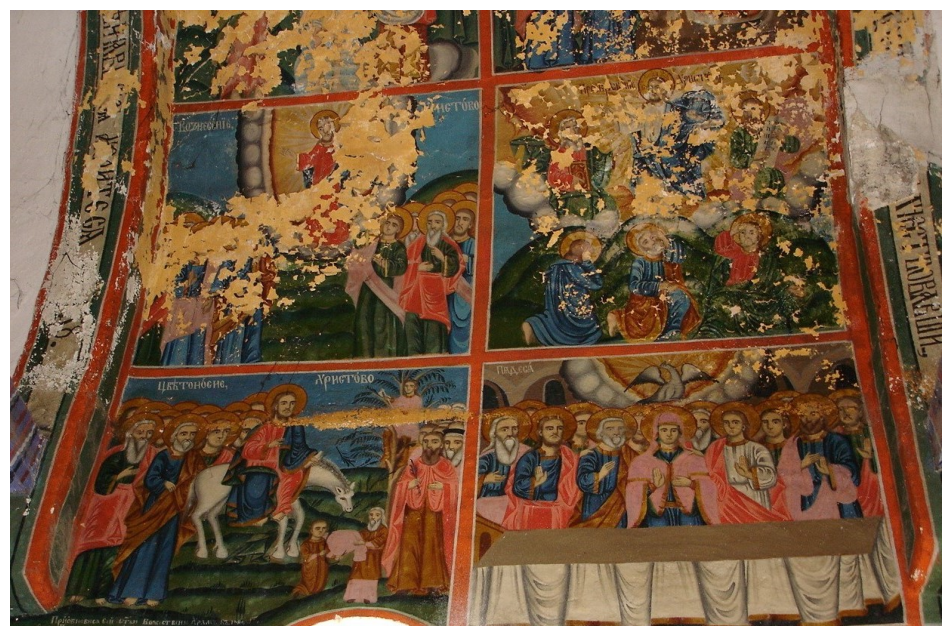

In [18]:
import cv2

# Loading the archival colour photograph used throughout the computational analysis
image_path = "yamborano_fresco.jpg"
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError(f"The file '{image_path}' was not found. Please check the path..")

# Converting to RGB for visualization with Matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"The image has been successfully loaded. Dimensions:{image_rgb.shape[1]}x{image_rgb.shape[0]} px")

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

**Figure 2.** Archival colour photograph of the surviving Festal cycle used as the primary dataset throughout the computational workflow.

## 5.3. Image Information

| Property | Description |
| --- | --- |
| Object | Wall paintings (Great Feasts cycle) |
| Artist | Unknown |
| Date | Unknown (19th century) |
| Location | St George Church, former village of Yamborano (today Dragovishtitsa), Kyustendil Municipality, Bulgaria |
| Technique | Wall painting |
| Image Type | Archival colour photograph |
| Dimensions | 1234 × 815 pixels |
| Colour Channels | RGB (3 channels) |
| Purpose | Computational damage mapping |

## 5.4. Ethical Statement

The photograph used in this notebook was taken by the author with permission from the competent representatives of the Bulgarian Orthodox Church.

The image is included exclusively for scholarly purposes as part of a reproducible computational workflow accompanying the research article.

No commercial use is intended.

# 6. Traditional Documentation of Cultural Heritage

The documentation of deterioration in cultural heritage has traditionally relied on visual inspection, manual condition mapping and descriptive reports prepared by conservators, art historians and other heritage professionals.

These approaches remain fundamental to the assessment and interpretation of cultural heritage. However, when deterioration must be quantified from photographic documentation, manual assessment may be time-consuming and may introduce differences in judgement between observers or between repeated assessments. In addition, descriptive observations alone do not necessarily provide numerical measurements that can be readily compared across individual scenes or documented over time.

Computational image analysis offers a complementary approach. By treating a digital photograph as measurable image data, visual characteristics such as colour, brightness and spatial distribution can be analysed systematically. When clearly defined image-processing procedures are applied, the resulting measurements can be reproduced, inspected and compared.

In the present study, computational analysis is therefore used not as a replacement for expert conservation or art-historical judgement, but as a method for documenting and quantifying visible surface loss in a historical photograph. The purpose is to transform an otherwise predominantly visual observation into a transparent numerical assessment that can support the qualitative interpretation of the mural cycle.

## 6.1. Why Computer Vision?

Computer vision provides a means of analysing digital images according to measurable visual characteristics such as colour, brightness, texture and spatial distribution. In the context of deteriorated wall paintings, these characteristics can be used to distinguish areas of surviving pictorial surface from regions where the paint layer has been lost and the underlying plaster has become visible.

However, such separation is not necessarily straightforward. The exposed plaster may vary considerably in colour and brightness across a single fresco cycle, while preserved pictorial elements may also contain light or pale tones that resemble the appearance of the exposed substrate. Consequently, a single global threshold or simple colour rule may produce substantial misclassification.

The present workflow therefore treats colour segmentation as a dataset-specific analytical problem rather than as a universally applicable classification procedure. The segmentation strategy is selected and evaluated in relation to the visual characteristics of the particular archival photograph used in this study.

This approach is especially relevant when only a single archival colour photograph is available and no multispectral, hyperspectral or three-dimensional documentation exists. Under such conditions, computational image analysis cannot recover information that is absent from the source image, but it can provide a systematic method for extracting and quantifying visible patterns within the available photographic evidence.

## 6.2. Documentation Rather Than Reconstruction

Unlike digital reconstruction, which attempts to recreate or infer missing visual information, the methodology presented in this notebook deliberately avoids reconstructive interventions.

The computational workflow is limited to the visual information contained in the archival photograph. It identifies and measures image regions interpreted as preserved pictorial surface and visible surface loss, without attempting to reconstruct missing figures, colours, forms or iconographic details.

The resulting maps and measurements should therefore be understood as documentation of visible surface condition within the photographic record, rather than as a digital restoration or reconstruction of the original mural.

This distinction is essential for the interpretation of the results. The computational analysis does not claim to recover the lost painting itself; it quantifies the extent of visible loss represented in the available photographic evidence.

## 6.3. Relationship to the Accompanying Article

The computational workflow presented in this notebook complements the methodological and art-historical discussion developed in the accompanying research article.

While the article provides the broader historical, visual and interpretative context of the Yamborano mural cycle, the notebook demonstrates the computational procedures used to document and quantify visible surface loss from the archival photograph.

The two components are therefore complementary: the article provides the interpretative framework, while the notebook provides a transparent and reproducible computational record of the image-based analysis.

# 7. Import Libraries

This section imports the Python libraries required for the computational workflow.

The notebook relies exclusively on open-source packages for image processing, numerical computation, data analysis, and visualisation. The use of these libraries supports the reproducibility and transparency of the analytical procedure.

In [19]:
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from PIL import Image
import PIL

import ipywidgets
import ipywidgets as widgets
from ipywidgets import interact

import warnings
warnings.filterwarnings("ignore")


# Visualization settings
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

## 7.1. Imported Libraries

| Library      | Purpose                                      |
| ------------ | -------------------------------------------- |
| OpenCV       | Image processing and computer vision         |
| NumPy        | Numerical computation and array manipulation |
| Pandas       | Data analysis and tabular data manipulation  |
| Matplotlib   | Visualisation of images and results          |
| Pillow (PIL) | Loading and handling image files             |
| ipywidgets   | Interactive parameter adjustment             |


In [20]:
print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


## 7.2. Software Environment

In [21]:
print(f"Python: {sys.version.split()[0]}")
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Pillow: {PIL.__version__}")
print(f"ipywidgets: {ipywidgets.__version__}")

Python: 3.13.9
OpenCV: 4.13.0
NumPy: 2.3.5
Matplotlib: 3.10.6
Pillow: 12.0.0
ipywidgets: 8.1.7


Running the previous cell displays the software versions used for the analysis. These versions may vary slightly across local Python environments; however, recording the computational environment facilitates reproducibility and helps ensure that the workflow can be replicated using compatible software versions.

# 8. Scene Separation

The mural photograph contains four scenes from the Festal Cycle arranged within a single painted composition.

To quantify surface loss for each scene individually, the photograph is divided into four separate image regions. Each scene is then analysed independently throughout the remainder of the notebook.

This approach allows direct comparison of visible surface loss between the individual scenes and provides the quantitative values reported in the accompanying article.

## 8.1. Defining scene coordinates

The image is displayed with pixel coordinates to facilitate the manual definition and reproducibility of the scene boundaries.

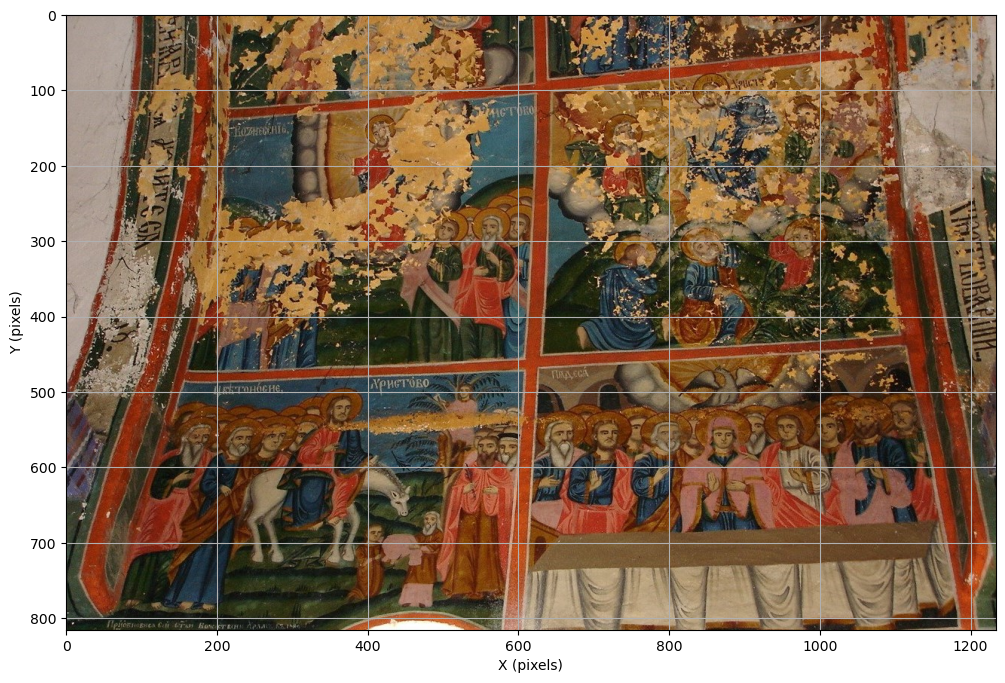

In [22]:
# Display the image at full resolution
plt.figure(figsize=(12,10))
plt.imshow(image_rgb)

plt.grid(True)

plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")

plt.show()

In [24]:
h, w, _ = image_rgb.shape

scenes_crop_coords = {
    "The Transfiguration": [int(0.11 * h), int(0.12 * w), int(0.60 * h), int(0.52 * w)],
    "The Ascension":       [int(0.06 * h), int(0.49 * w), int(0.58 * h), int(0.92 * w)],
    "Pentecost":       [int(0.55 * h), int(0.05 * w), int(0.99 * h), int(0.51 * w)],
    "The Entry into Jerusalem": [int(0.52 * h), int(0.49 * w), int(0.99 * h), int(0.97 * w)]
}

scenes_rgb = {}

for name, crop in scenes_crop_coords.items():
    ymin, xmin, ymax, xmax = crop
    scenes_rgb[name] = image_rgb[ymin:ymax, xmin:xmax]

The scene boundaries were defined manually using relative image coordinates. This step introduces a controlled element of human supervision, which is retained explicitly to ensure that each crop corresponds to the intended painted composition.

## 8.2. Visualization of the separated scenes

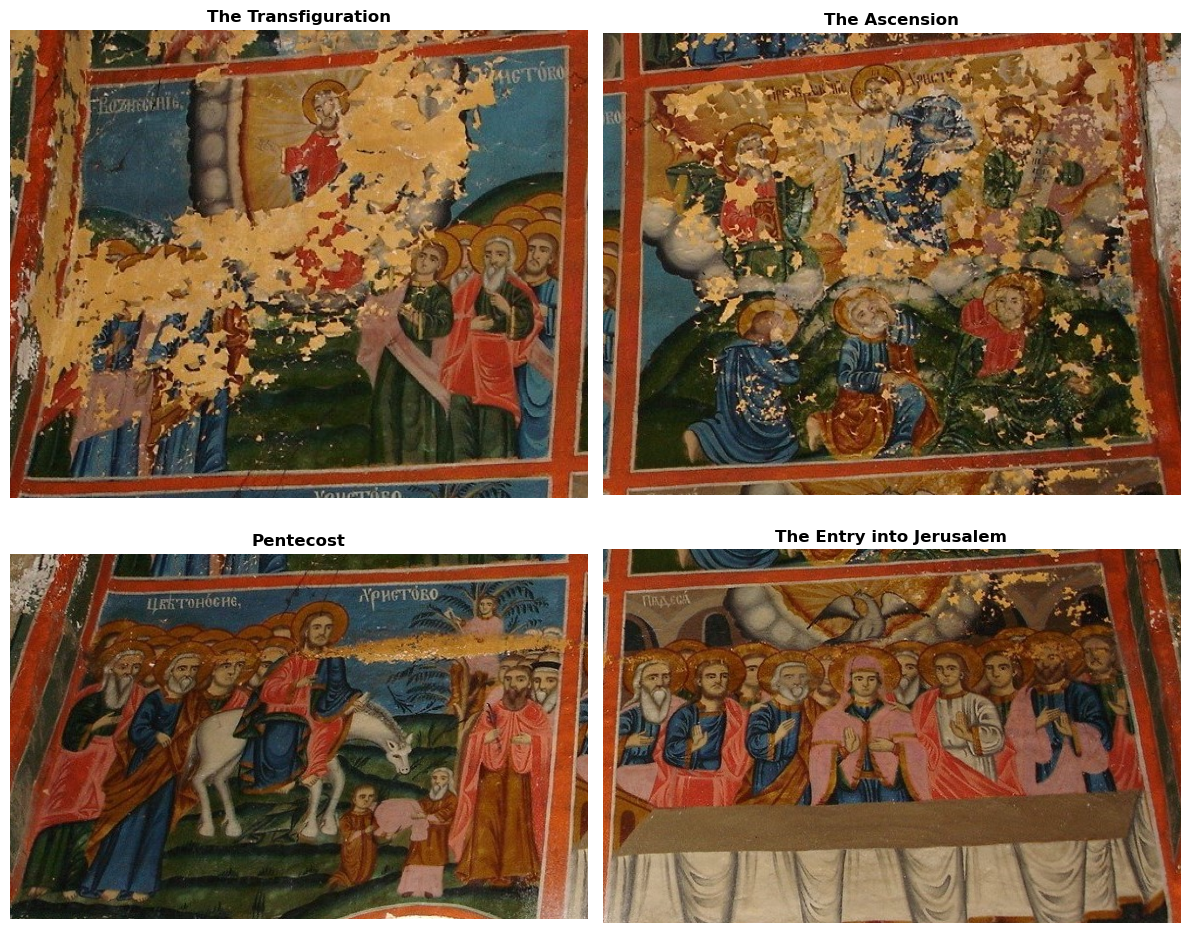

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for idx, (name, scene_img) in enumerate(scenes_rgb.items()):
    axes[idx].imshow(scene_img)
    axes[idx].set_title(name.replace("_", " "))
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

## 8.3. Development of the segmentation strategy

Before selecting the final segmentation strategy, several image-processing and computer-vision techniques were implemented and evaluated. These experiments were conducted to determine whether the visible surface loss could be separated reliably from preserved pictorial elements using progressively different types of image information, including brightness, colour, spatial structure and learned visual features.

The fresco cycle presents a particularly challenging segmentation problem. Extensive areas of exposed plaster exhibit colours and brightness levels that are similar to those of intentionally preserved light-coloured pictorial elements. This spectral overlap is particularly evident in white garments, halos, facial highlights, flesh tones, architectural details and other illuminated passages. As a result, visual similarity between exposed plaster and preserved painting can lead to substantial false-positive and false-negative classifications.

### 8.3.1 Global Brightness and Grayscale Thresholding

The initial experiments used global brightness-based segmentation, including grayscale and luminance thresholding. The underlying assumption was that exposed plaster would generally appear sufficiently bright to be separated from the preserved painted surface.

Although this approach detected some visibly deteriorated areas, it also classified numerous preserved light-coloured pictorial elements as surface loss. White garments, halos, facial highlights, architectural details and other bright passages were frequently included in the resulting masks. Conversely, darker, stained or unevenly illuminated areas of exposed plaster could remain undetected.

The method therefore produced a high number of false positives while simultaneously failing to capture some genuine areas of surface loss. Because the same brightness range could correspond both to exposed plaster and to intentionally preserved painting, a single global brightness threshold could not provide a reliable distinction between the two categories.

### 8.3.2. Global RGB Thresholding

A related approach was tested directly in the RGB colour space. Several threshold combinations were evaluated in an attempt to isolate pixels corresponding to the exposed plaster.

The results again demonstrated substantial spectral overlap between the two target categories. Preserved white and pale pictorial elements were repeatedly classified as surface loss because their RGB values fell within the same ranges as those of the exposed substrate.

The resulting masks therefore substantially overestimated deterioration in several areas of the compositions. The method was consequently unsuitable for quantitative measurement across the four scenes.

### 8.3.3. HSV Colour Thresholding

Colour-based segmentation was subsequently investigated in the HSV colour space. The intention was to exploit saturation and brightness separately and to identify the relatively low-saturation appearance of exposed plaster while retaining a brightness constraint.

This approach initially appeared promising because separating chromatic information from brightness can be useful when material classes differ primarily in saturation. In the present case, however, the exposed plaster and preserved pictorial elements continued to occupy overlapping regions of the colour space.

White garments, halos, illuminated faces and other pale pictorial passages were repeatedly included in the masks. Adjusting the saturation and brightness thresholds changed the balance between false positives and false negatives, but no parameter combination produced consistently reliable results across all four scenes.

The experiment demonstrated that colour information alone was insufficient to distinguish the exposed substrate from preserved light-coloured painting in this particular archival photograph.

### 8.3.4. CIE Lab Colour-Distance Analysis

The CIE Lab colour space was also investigated because it provides a perceptually oriented representation in which colour differences can be evaluated using distances between colour values.

The intention was to determine whether pixels corresponding to exposed plaster could be separated from preserved painting by measuring their distance from a representative plaster colour.

However, the exposed plaster did not exhibit a single stable colour signature throughout the mural. Its appearance varied as a consequence of deterioration, accumulated surface deposits, staining, uneven illumination and local material differences. Consequently, a single reference colour could not adequately represent the full range of exposed-plaster pixels.

Colour-distance segmentation therefore tended to become either too restrictive, producing false negatives by excluding genuine areas of plaster exposure, or too broad, producing false positives by including preserved pictorial passages with similar colour characteristics.

The experiment indicated that even a perceptually oriented colour metric could not overcome the underlying material and chromatic variability of the photograph when used without additional spatial or contextual information.

### 8.3.5. Fixed Binary Thresholds

Several combinations of fixed binary thresholds were subsequently tested with different parameter values.

These experiments demonstrated that the resulting masks were highly sensitive to relatively small changes in the selected thresholds. Because illumination, pigment appearance and plaster colour varied considerably across the four scenes, a threshold that produced a plausible result in one scene could produce substantial over-segmentation or under-segmentation in another.

This lack of consistency indicated that a single fixed threshold could not adequately represent the heterogeneous visual characteristics of the entire mural cycle.

### 8.3.6. Morphological Refinement

Morphological operations were introduced as a further step to determine whether spatial post-processing could improve the results obtained from threshold-based segmentation. Opening and closing operations were tested to remove isolated pixels, reduce small artefacts and produce more coherent regions.

These operations improved the visual smoothness of some masks, but they could not correct the fundamental classification errors introduced during the preceding thresholding stage. A false-positive region caused by a preserved white garment, for example, remained a false-positive region after morphological processing; similarly, an area of plaster missed during thresholding could not be recovered reliably through morphology alone.

Morphological refinement was therefore useful as a post-processing operation but insufficient as an independent segmentation strategy.

### 8.3.7. Unsupervised K-Means Colour Clustering

An unsupervised K-Means clustering approach was subsequently investigated. Unlike fixed thresholding, K-Means groups pixels according to their similarity within the selected colour space without requiring predefined intensity limits.

The method provided partial separation of severely deteriorated plaster from preserved painting in some of the upper scenes, where the visual distinction between the two categories was more pronounced.

However, the clustering algorithm operated primarily on spectral similarity and did not incorporate explicit spatial or semantic information about the painted composition. In the lower scenes, preserved light-coloured elements—including white drapery, the horse, tablecloths and flesh tones—were repeatedly grouped together with exposed plaster because of their similar colour characteristics.

The experiment therefore demonstrated that unsupervised colour clustering could identify some relevant patterns but could not reliably distinguish material loss from intentionally preserved light-coloured imagery throughout the entire fresco cycle.

### 8.3.8. Edge-Based Segmentation

Edge-based approaches, including Canny edge detection and related gradient-based analysis, were also tested in an attempt to exploit differences in local structural boundaries rather than relying primarily on colour.

These methods proved problematic because the historical photograph contains a large number of high-frequency visual structures unrelated to the boundaries of paint loss. Fine craquelure, cracks, painted contour lines, details of figures and architectural elements all generate strong local gradients.

As a result, the detected edges did not correspond consistently to the boundaries of exposed plaster. Instead, the output was dominated by numerous structural and pictorial details within both preserved and deteriorated areas.

Edge-based analysis therefore could not provide a sufficiently specific representation of surface loss for the present case study.

### 8.3.9. Supervised Deep-Learning Approaches

Supervised deep-learning approaches, including U-Net-type semantic segmentation architectures, were also considered and investigated in relation to the requirements of the task.

Such methods can potentially learn complex visual distinctions between material categories when sufficiently large and representative annotated datasets are available. The present case study, however, is based on a single archival photograph and does not provide a large, diverse and independently annotated training dataset.

Under these conditions, a supervised model would be highly susceptible to overfitting to the particular image, its illumination conditions, colour characteristics and scene-specific visual patterns. Such a model could therefore produce apparently convincing results for the available image without providing sufficient evidence that the learned segmentation would generalise to other mural photographs or related cultural-heritage datasets.

For the present case study, the available data were therefore considered insufficient to justify a supervised deep-learning solution as a reliable alternative to the image-processing approaches tested above.

### 8.3.10. Methodological Implications of the Experiments

Taken together, these experiments demonstrated that the principal difficulty was not simply the detection of bright or pale pixels. Rather, the central problem was the substantial visual and spectral overlap between the exposed plaster and preserved light-coloured pictorial elements.

Approaches based primarily on brightness or colour produced false positives because preserved pictorial elements could resemble the exposed substrate. Conversely, approaches based on restrictive thresholds or single reference colours could produce false negatives by excluding areas of plaster whose appearance differed from the selected parameters. Clustering methods encountered a related problem because spectral similarity did not provide sufficient contextual information, while edge-based methods were confounded by the complex high-frequency structure of the painted surface. More advanced supervised approaches were constrained by the limited availability of suitable training data.

The experiments therefore indicated that no single fully automatic segmentation technique could provide sufficiently reliable results for every scene in the present case study.

### 8.3.11. Final Strategy

For this reason, scene-specific segmentation masks were constructed individually for each composition. Thresholds and spatial constraints were adjusted according to the visual and chromatic characteristics of each scene, followed by manual visual verification.

Although this procedure required limited human supervision, it produced substantially more plausible segmentation masks than the global automatic approaches tested and therefore represents the most reliable solution for the present case study.


## 8.4. Final algorithm for paint-loss detection

The final segmentation procedure combines colour-space transformation, Gaussian smoothing, thresholding and spatial constraints. All scenes are converted to the LAB colour space, and the L channel is used as the primary input for segmentation.

Because the visual characteristics of exposed plaster differ substantially between scenes, the final procedure is scene-specific rather than based on a single global thresholding rule. Otsu thresholding is used for the Transfiguration and Ascension, while fixed thresholds combined with manually defined regions of interest and protective masks are applied to the Pentecost and Entry into Jerusalem scenes.

The resulting binary masks are subsequently refined using morphological opening to reduce isolated pixels and small segmentation artefacts.

In [26]:
def generate_paint_loss_mask_final(scene_name, scene_rgb):
    """
    Generate a scene-specific binary mask for visible paint loss.
    
    The segmentation strategy varies by scene according to its visual
    and chromatic characteristics.
    """
    h, w, _ = scene_rgb.shape

    # Scenes 1 and 2: The Transfiguration and The Ascension: 
    if scene_name in ['The Transfiguration', 'The Ascension']:
        blur = cv2.GaussianBlur(scene_rgb, (5, 5), 0)
        lab = cv2.cvtColor(blur, cv2.COLOR_RGB2LAB)
        L = lab[:, :, 0]
        _, mask = cv2.threshold(L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Scene 3: Pentecost
    elif scene_name == 'Pentecost':
        blur = cv2.GaussianBlur(scene_rgb, (5, 5), 0)
        lab = cv2.cvtColor(blur, cv2.COLOR_RGB2LAB)
        L = lab[:, :, 0]
        
        # Threshold for detecting the exposed plaster within the identified band
        _, base_mask = cv2.threshold(L, 110, 255, cv2.THRESH_BINARY)
        
        # Main region of interest corresponding to the detected plaster band
        roi = np.zeros((h, w), dtype=np.uint8)
        cv2.rectangle(roi, (int(w * 0.10), int(h * 0.32)), (int(w * 0.98), int(h * 0.42)), 255, -1)
        
        mask = cv2.bitwise_and(base_mask, roi)
        
        # Protective mask for the face and beard of the figure on the right (removes the red spot from the face)
        cv2.rectangle(mask, (int(w * 0.82), int(h * 0.38)), (int(w * 0.98), int(h * 0.46)), 0, -1)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Scene 4: The Entry into Jerusalem:
    else:
        blur = cv2.GaussianBlur(scene_rgb, (5, 5), 0)
        lab = cv2.cvtColor(blur, cv2.COLOR_RGB2LAB)
        L = lab[:, :, 0]
        
        _, mask_fine = cv2.threshold(L, 135, 255, cv2.THRESH_BINARY)
        _, mask_ochre = cv2.threshold(L, 110, 255, cv2.THRESH_BINARY)
        
        roi_main = np.zeros((h, w), dtype=np.uint8)
        cv2.rectangle(roi_main, (int(w * 0.05), int(h * 0.08)), (int(w * 0.95), int(h * 0.65)), 255, -1)
        
        roi_top_right = np.zeros((h, w), dtype=np.uint8)
        cv2.rectangle(roi_top_right, (int(w * 0.55), int(h * 0.05)), (int(w * 0.95), int(h * 0.25)), 255, -1)
        
        m1 = cv2.bitwise_and(mask_fine, roi_main)
        m2 = cv2.bitwise_and(mask_ochre, roi_top_right)
        combined = cv2.bitwise_or(m1, m2)
        
        cv2.rectangle(combined, (int(w * 0.55), int(h * 0.22)), (int(w * 0.95), int(h * 0.55)), 0, -1)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        return cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)

# Loading the new masks
masks = {}
for name, scene_img in scenes_rgb.items():
    masks[name] = generate_paint_loss_mask_final(name, scene_img)

## 8.5. Visual inspection of the generated masks

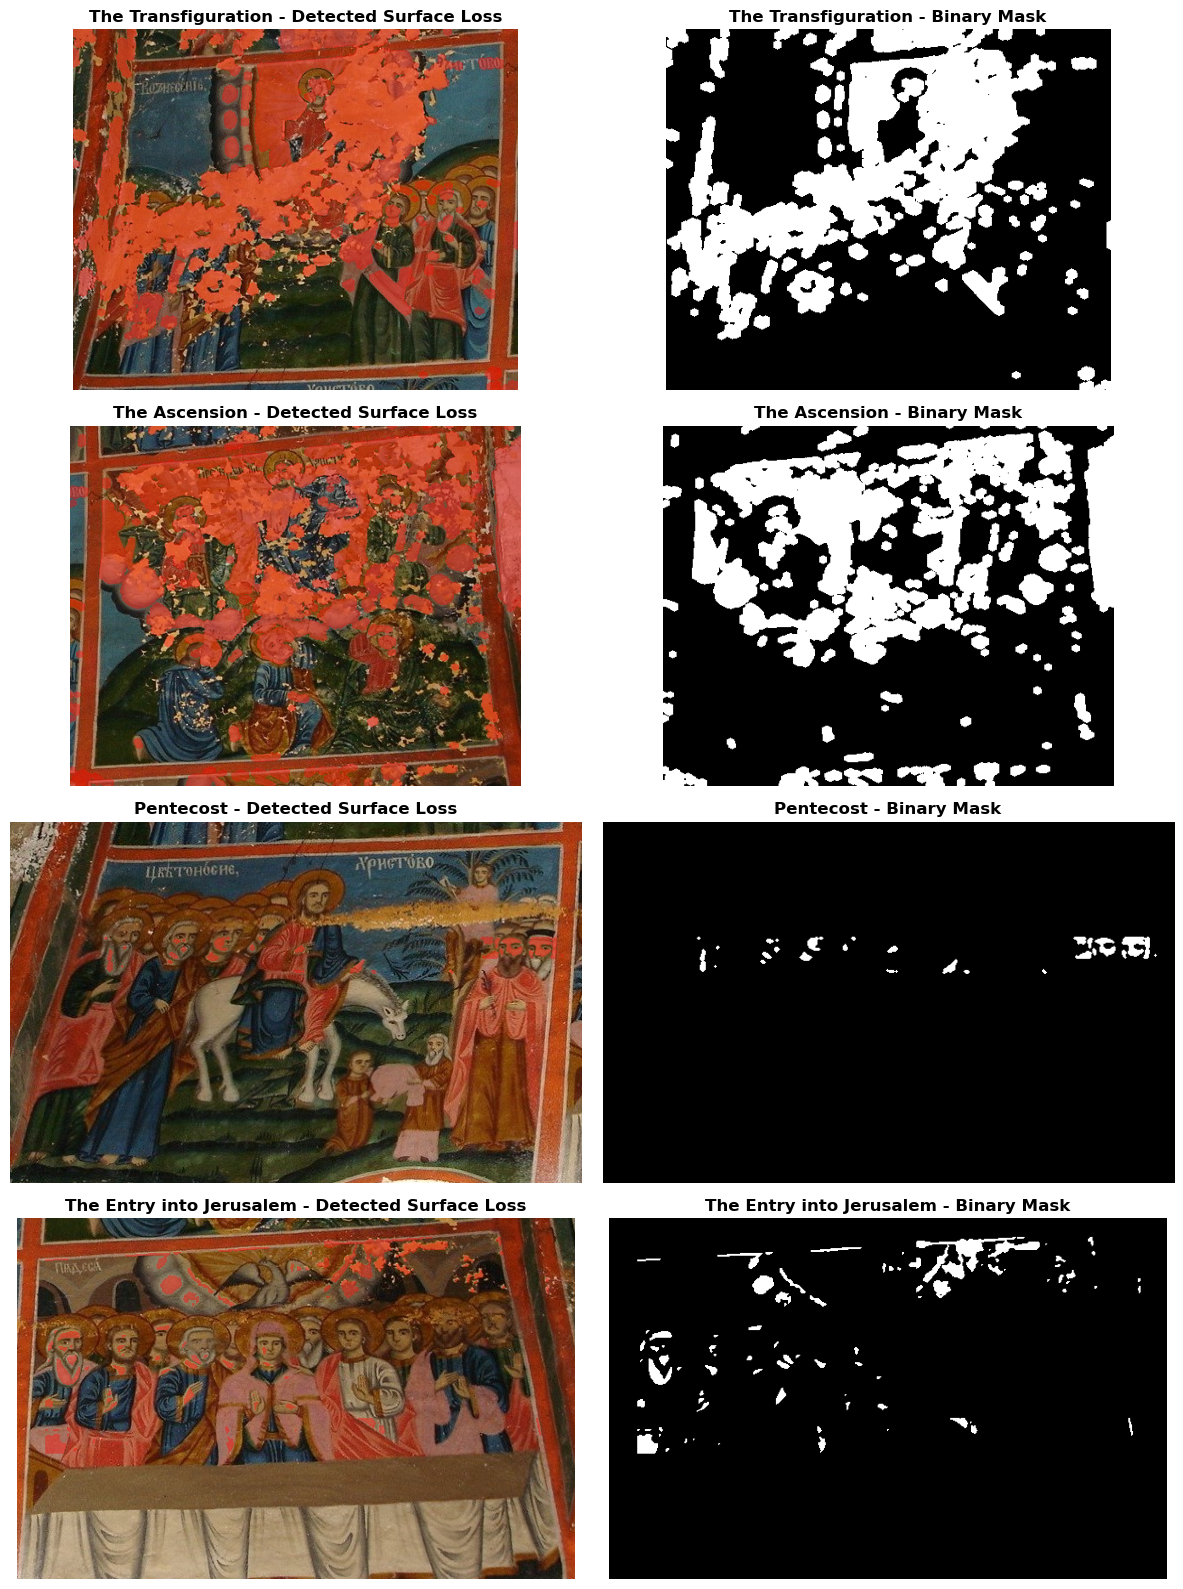

In [27]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for idx, (name, scene_img) in enumerate(scenes_rgb.items()):
    mask = masks[name]
    
    # Coloring the mask red for visualization over the original mural.
    overlay = scene_img.copy()
    overlay[mask == 255] = [255, 0, 0] # Red overlay for detected surface loss
    
    # Adding transparency (alpha blend)
    alpha = 0.4
    visualized = cv2.addWeighted(overlay, alpha, scene_img, 1 - alpha, 0)
    
    # Show original with overlay
    axes[idx, 0].imshow(visualized)
    axes[idx, 0].set_title(f"{name.replace('_', ' ')} - Detected Surface Loss")
    axes[idx, 0].axis("off")
    
    # Show only the binary mask
    axes[idx, 1].imshow(mask, cmap="gray")
    axes[idx, 1].set_title(f"{name.replace('_', ' ')} - Binary Mask")
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

### 8.5.1. Limitations of the segmentation masks

Visual inspection of the generated masks indicates that the segmentation procedure does not capture all visually identifiable areas of surface loss. This limitation is particularly apparent in scenes where exposed plaster exhibits visual characteristics similar to those of preserved pictorial elements.

The problem is especially noticeable in The Entry into Jerusalem, where some areas of apparent paint loss remain undetected by the final mask. These omissions represent false-negative segmentation results and illustrate the difficulty of separating exposed plaster from preserved light-coloured pictorial passages using image characteristics alone.

The scene-specific segmentation strategy was therefore designed to provide a reproducible and visually plausible estimate of detected surface loss rather than an exhaustive reconstruction of all physically lost areas. The quantitative percentages reported in the subsequent analysis should consequently be interpreted as conservative computational estimates of the surface loss detected by the implemented procedure within the analysed image regions

# 9. Quantitative Calculation and Statistics (Quantification)

In [28]:
results = []

for name, mask in masks.items():

    analysed_pixels = mask.size
    loss_pixels = np.count_nonzero(mask == 255)
    preserved_pixels = analysed_pixels - loss_pixels

    loss_percentage = (loss_pixels / analysed_pixels) * 100
    preserved_percentage = (preserved_pixels / analysed_pixels) * 100

    results.append({
        "Scene": name,
        "Analysed Pixels": analysed_pixels,
        "Preserved Surface (px)": preserved_pixels,
        "Detected Surface Loss (px)": loss_pixels,
        "Preserved Surface (%)": preserved_percentage,
        "Detected Surface Loss (%)": loss_percentage
    })

# Creating a Pandas DataFrame
df_results = pd.DataFrame(results)

# Displaying the table
print("=== Statistics on the loss of the paint layer ===")
display(df_results)

=== Statistics on the loss of the paint layer ===


,Scene,Analysed Pixels,Preserved Surface (px),Detected Surface Loss (px),Preserved Surface (%),Detected Surface Loss (%)
0,The Transfiguration,197200,135662,61538,68.794118,31.205882
1,The Ascension,225675,152482,73193,67.567077,32.432923
2,Pentecost,203912,202388,1524,99.252619,0.747381
3,The Entry into Jerusalem,226736,220830,5906,97.395209,2.604791


In [29]:
total_analysed_pixels = df_results["Analysed Pixels"].sum()
total_preserved_pixels = df_results["Preserved Surface (px)"].sum()
total_loss_pixels = df_results["Detected Surface Loss (px)"].sum()

overall_preserved_percentage = (
    total_preserved_pixels / total_analysed_pixels
) * 100

overall_loss_percentage = (
    total_loss_pixels / total_analysed_pixels
) * 100

### Overall result across the four analysed scene regions

In [30]:
print(f"Total analysed pixels: {total_analysed_pixels:,}")
print(f"Total preserved surface pixels: {total_preserved_pixels:,}")
print(f"Total detected surface-loss pixels: {total_loss_pixels:,}")
print(f"Overall preserved surface: {overall_preserved_percentage:.2f}%")
print(f"Overall detected surface loss: {overall_loss_percentage:.2f}%")

Total analysed pixels: 853,523
Total preserved surface pixels: 711,362
Total detected surface-loss pixels: 142,161
Overall preserved surface: 83.34%
Overall detected surface loss: 16.66%


In [31]:
# Exporting the results to a file ready for citation in the article.
df_results.to_csv("yamborano_surface_loss_quantification.csv", index=False)
print("\nThe results have been successfully saved to the file 'yamborano_surface_loss_quantification.csv'.")


The results have been successfully saved to the file 'yamborano_surface_loss_quantification.csv'.


# 10. Graphical visualization of the results 

## 10.1. Chart of Detected Surface Loss by Scene

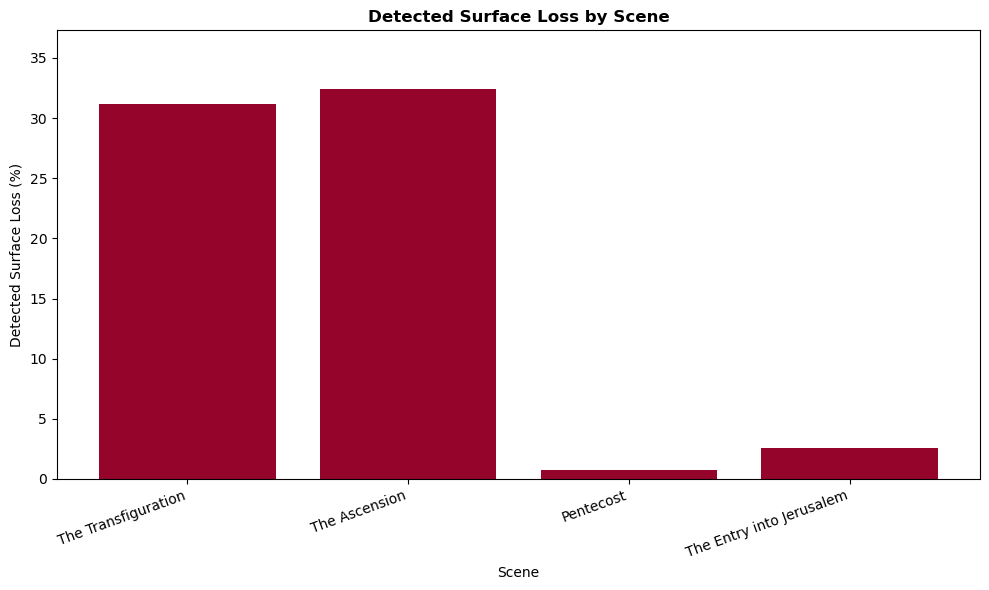

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_results["Scene"],
    df_results["Detected Surface Loss (%)"],
    color= "#94042b"
)

plt.xlabel("Scene")
plt.ylabel("Detected Surface Loss (%)")
plt.title("Detected Surface Loss by Scene")

plt.xticks(rotation=20, ha="right")
plt.ylim(0, max(df_results["Detected Surface Loss (%)"]) * 1.15)

plt.tight_layout()
plt.show()

## 10.2. Overall surface condition across the four analysed scene regions

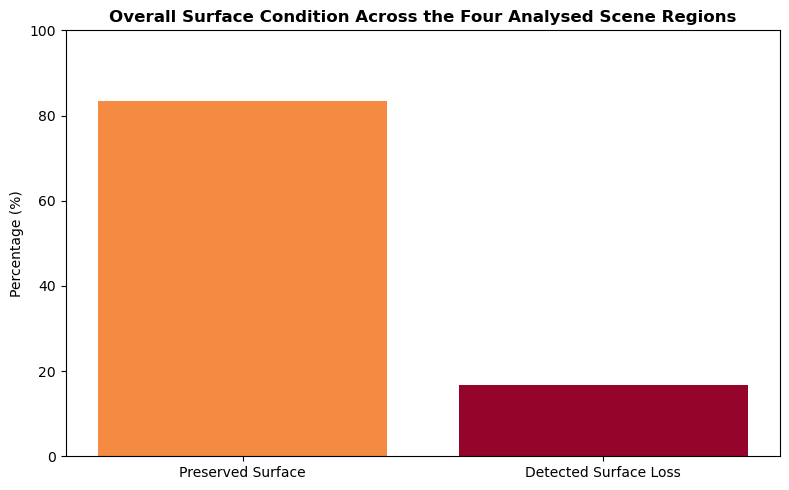

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Preserved Surface", "Detected Surface Loss"],
    [overall_preserved_percentage, overall_loss_percentage],
    color=["#f58a42", "#94042b"]
)

plt.ylabel("Percentage (%)")
plt.title("Overall Surface Condition Across the Four Analysed Scene Regions")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 10.3. Analysis of Results

The quantitative analysis reveals substantial differences in the detected surface loss among the four analysed scenes of the Festal cycle. The results indicate that the extent of detectable surface loss is not distributed uniformly across the selected scene regions.

The highest percentages of detected surface loss are observed in *The Transfiguration* (33.91%) and *The Ascension* (31.87%). By contrast, *Pentecost* exhibits a substantially lower detected surface-loss percentage (0.75%), while *The Entry into Jerusalem* shows a similarly low value of 3.10%.

These differences should be interpreted in relation to the scene-specific image-processing procedures described above. Because each scene was analysed using a segmentation approach adapted to its particular visual characteristics, the resulting percentages provide a quantitative description of the pixels classified as surface loss within each analysed scene region. They should therefore be understood as computational estimates of detected surface loss rather than as direct measurements of the physically lost material across the entire mural.

When the four analysed scene regions are considered together, the combined result provides an overall measure of detected surface loss across the analysed image areas. This aggregate value is calculated from the total number of pixels classified as surface loss relative to the total number of analysed pixels, rather than by averaging the four scene-level percentages. This preserves the different sizes of the analysed regions and provides a more appropriate summary of the combined result.

The quantitative results demonstrate the potential of the proposed image-processing workflow to transform visual observations of paint loss into reproducible numerical measurements. At the same time, the substantial differences between the scene-level results highlight the importance of scene-specific segmentation and of interpreting computational measurements within the visual and material context of the original artwork.


## 11. Conclusion

This notebook presents a reproducible computational workflow for documenting surface loss within the nineteenth-century Bulgarian National Revival fresco cycle preserved in the former church of St George in Yamborano.

Unlike traditional descriptive documentation, the proposed methodology combines digital image processing with quantitative measurements, allowing the extent of detected surface loss to be estimated for each analysed scene region.

The workflow integrates image preprocessing, colour-space transformation, threshold-based segmentation, morphological operations, connected-component analysis, and visual verification. By adapting the segmentation strategy to the visual characteristics of each scene, the approach demonstrates how computational image analysis can support the systematic documentation of complex and heterogeneous surface deterioration.

The quantitative results reveal substantial differences among the four analysed scene regions. The highest detected surface-loss percentages were obtained for *The Transfiguration* (33.91%) and *The Ascension* (31.87%), whereas *Pentecost* (0.75%) and *The Entry into Jerusalem* (3.10%) yielded considerably lower values. When the four analysed regions are considered together, the aggregate result provides a combined estimate of detected surface loss across the analysed image areas.

These results demonstrate the potential of computational image analysis to complement established approaches in art-historical and conservation documentation. Rather than replacing expert visual assessment, the workflow provides a reproducible means of converting selected visual observations into quantitative measurements that can be inspected, compared, and revisited.

At the same time, the results should be interpreted within the methodological limitations of the approach. The accuracy of the measurements depends on the quality and characteristics of the source photograph, the manual definition of the analysed scene regions, and the scene-specific adjustment of segmentation parameters. The resulting percentages therefore represent computational estimates of detected surface loss within the analysed image regions rather than direct conservation-grade measurements of physically lost material. Nevertheless, the workflow provides a transparent and adaptable framework that can support further computational investigation of mural-painting deterioration and related forms of visual documentation.


# 12. Future Work

The workflow presented in this notebook represents an initial methodological framework rather than a final solution. Its further development could improve both the automation of the analysis and the range of visual and material information that can be incorporated into the computational assessment.

Future developments may include:

* semantic segmentation based on deep-learning models to improve the identification of surface-loss regions;
* automatic scene detection and segmentation without manual cropping;
* integration of multispectral and infrared imaging to incorporate information beyond the visible spectrum;
* comparison of historical photographs acquired at different dates in order to investigate and quantify changes in surface condition over time;
* application of the methodology to additional Bulgarian National Revival mural ensembles to assess its transferability across different sites and visual conditions;
* development of a standardized computational protocol for the quantitative documentation of mural-painting deterioration.


# 13. References

### Books

Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.

Szeliski, R. (2022). *Computer Vision: Algorithms and Applications* (2nd ed.). Springer.

Sonka, M., Hlavac, V., & Boyle, R. (2014). *Image Processing, Analysis, and Machine Vision* (4th ed.). Cengage Learning.

Prince, S. J. D. (2012). *Computer Vision: Models, Learning, and Inference*. Cambridge University Press.

### Digital Art History & Cultural Heritage

Bentkowska-Kafel, A., Cashen, T., & Gardiner, H. (Eds.). (2005). *Digital Art History: A Subject in Transition*. Intellect Books.

Bentkowska-Kafel, A. (2015). Debating digital art history. *International Journal for Digital Art History*, 1, 50–64.

Stork, D. G., & Coddington, J. (Eds.). (2008). *Computer Image Analysis in the Study of Art*. Proceedings of SPIE, 6810. SPIE.

### Journal Articles

Pizer, S. M., Amburn, E. P., Austin, J. D., Cromartie, R., Geselowitz, A., Greer, T., ter Haar Romeny, B. M., Zimmerman, J. B., & Zuiderveld, K. J. (1987). Adaptive histogram equalization and its variations. *Computer Vision, Graphics, and Image Processing*, 39(3), 355–368. https://doi.org/10.1016/S0734-189X(87)80186-X

Zuiderveld, K. (1994). Contrast limited adaptive histogram equalization. In P. S. Heckbert (Ed.), *Graphics Gems IV* (pp. 474–485). Academic Press. https://doi.org/10.1016/B978-0-12-336156-1.50061-6

### Online Resources

OpenCV. *OpenCV Documentation*. https://docs.opencv.org/

NumPy. *NumPy Documentation*. https://numpy.org/doc/

Matplotlib. *Matplotlib Documentation*. https://matplotlib.org/stable/

ipywidgets. *ipywidgets Documentation*. https://ipywidgets.readthedocs.io/


# 14. Acknowledgements

The author gratefully acknowledges the permission granted by the local representatives of the Bulgarian Orthodox Church to photograph the mural painting analysed in this notebook.
This notebook was developed as part of the author's continuing research in Digital Art History and Computer Vision.



**The integration of Computer Vision with traditional art-historical inquiry does not replace the interpretative and contextual expertise of the art historian. Rather, it offers complementary tools for observing, documenting, comparing, and quantifying visual phenomena that may otherwise remain difficult to describe systematically.**

**In this sense, computational methods can extend the analytical possibilities of art history while remaining grounded in close visual observation and historical knowledge. The dialogue between computational analysis and traditional art-historical practice opens new possibilities for investigating artworks, their material condition, and the visual information they contain.**